# Workshop D.2: Evaluating Learned Representations


In [1]:
# --- Imports: standard libs, numpy/pandas, plotting, torch, torchvision, sklearn
import os
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset

import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import functional as TF
from torchvision.models import (resnet18, resnet34, ResNet18_Weights, ResNet34_Weights)
from torch.utils.data import random_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error
import importlib
import matplotlib.pyplot as plt
# Suppress noisy warnings in notebook output
warnings.filterwarnings("ignore")

# 1 (and 2). DL and load Dataset of intereset
## 1.1 DL and Load properly into a D={X,Y}

In [3]:
from data import download_dsprites, load_dSprites
DSPRITES_PATH = download_dsprites()
dsprites = load_dSprites(DSPRITES_PATH)

File already exists: data/dsprites/dsprites_ndarray_co1sh3sc6or40x32y32_64x64.npz
Keys in dataset:
['metadata', 'imgs', 'latents_classes', 'latents_values']

Shapes:
imgs: (737280, 64, 64)
latents_classes: (737280, 6)
latents_values: (737280, 6)

Latent names from metadata:
('color', 'shape', 'scale', 'orientation', 'posX', 'posY')

Latent sizes from metadata:
[ 1  3  6 40 32 32]

Tensor shapes:
X: torch.Size([737280, 1, 64, 64])
Y_classes: torch.Size([737280, 6])
Y_values: torch.Size([737280, 6])

Factor index:
0: color        |  1 unique class values | [0]
1: shape        |  3 unique class values | [0, 1, 2]
2: scale        |  6 unique class values | [0, 1, 2, 3, 4, 5]
3: rotation     | 40 unique class values | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
4: x_position   | 32 unique class values | [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 

#### Bellow: we will convert it into D={X, Y=[Y_classes, Y_values] }. 


$$\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N}$$

where:

$$x_i \in \mathbb{R}^{1\times64\times64}$$
and
$$y_i =
[
y_{\text{color}},
y_{\text{shape}},
y_{\text{scale}},
y_{\text{rotation}},
y_{x\text{-pos}},
y_{y\text{-pos}}
]$$

In [4]:
dataset = dsprites["dataset"]
X = dsprites["X"]
Y_classes = dsprites["Y_classes"]
Y_values = dsprites["Y_values"]
metadata = dsprites["metadata"]
FACTOR_INDEX = dsprites["factor_index"]

### the way the data is arranged and we can get the FVs directly:
Then for each disentanglement probe:
$$FV_k(x_i)=y_{i,k}$$
For example:
$$FV_{\text{shape}}(x_i)=y_{i,\text{shape}}$$

In [5]:
dataset.get_factor(199090, "scale")

tensor(4)

## 1.2 Now Train/Val/Test split and load into a pytorch Dataloader

In [6]:
# ------------------------------------------------------------# Train / validation / test split# ------------------------------------------------------------
N = len(dataset)
n_train = int(0.8 * N)
n_val = int(0.1 * N)
n_test = N - n_train - n_val

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset, test_dataset = random_split( dataset, [n_train, n_val, n_test], generator=generator)

print("\nSplit sizes:")
print("train:", len(train_dataset))
print("val:  ", len(val_dataset))
print("test: ", len(test_dataset))


# ------------------------------------------------------------# DataLoaders# ------------------------------------------------------------
BATCH_SIZE = 128
train_loader = DataLoader( train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True,)
val_loader = DataLoader(val_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True,)
test_loader = DataLoader(test_dataset,batch_size=BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=True,)


Split sizes:
train: 589824
val:   73728
test:  73728


###  Evaluating one example to make sure all is good and works as expected

In [7]:
# ------------------------------------------------------------# Inspect one batch# ------------------------------------------------------------

batch = next(iter(train_loader))

batch_x = batch["x"]              # [B, 1, 64, 64]
batch_y = batch["y"]              # [B, 6]
batch_y_values = batch["y_values"]  # [B, 6]

print("\nBatch:")
print("batch_x:", batch_x.shape)
print("batch_y:", batch_y.shape)
print("batch_y_values:", batch_y_values.shape)

print("\nFirst 5 factor vectors:")
print(batch_y[:5])

print("\nAccess individual factors:")
for name, idx in FACTOR_INDEX.items():
    print(f"{name:12s}:", batch_y[:10, idx].tolist())


Batch:
batch_x: torch.Size([128, 1, 64, 64])
batch_y: torch.Size([128, 6])
batch_y_values: torch.Size([128, 6])

First 5 factor vectors:
tensor([[ 0,  2,  3,  8, 31, 22],
        [ 0,  2,  1, 39, 20, 20],
        [ 0,  1,  2, 20,  5,  4],
        [ 0,  2,  2, 34, 27, 17],
        [ 0,  2,  0, 11,  2, 14]])

Access individual factors:
color       : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
shape       : [2, 2, 1, 2, 2, 0, 2, 0, 1, 2]
scale       : [3, 1, 2, 2, 0, 2, 3, 2, 2, 3]
rotation    : [8, 39, 20, 34, 11, 28, 25, 32, 18, 25]
x_position  : [31, 20, 5, 27, 2, 18, 16, 28, 19, 1]
y_position  : [22, 20, 4, 17, 14, 15, 14, 17, 31, 31]


In [8]:
# ------------------------------------------------------------# Example: choose one factor for a probe# ------------------------------------------------------------

# Example target: shape
factor_name = "shape"
factor_idx = FACTOR_INDEX[factor_name]

x_probe = batch_x
y_probe = batch_y[:, factor_idx]

print(f"\nProbe target: {factor_name}")
print("x_probe:", x_probe.shape)
print("y_probe:", y_probe.shape)
print("unique labels in batch:", torch.unique(y_probe).tolist())


Probe target: shape
x_probe: torch.Size([128, 1, 64, 64])
y_probe: torch.Size([128])
unique labels in batch: [0, 1, 2]


tensor([ 0,  2,  3,  8, 31, 22])


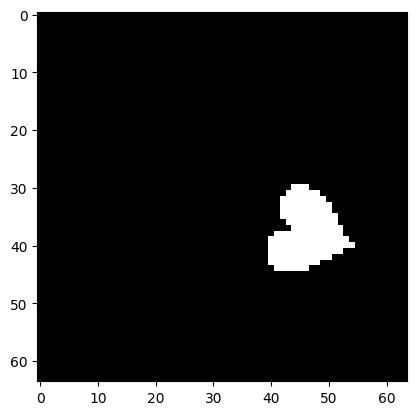

tensor([ 0,  1,  4, 38, 20, 14])


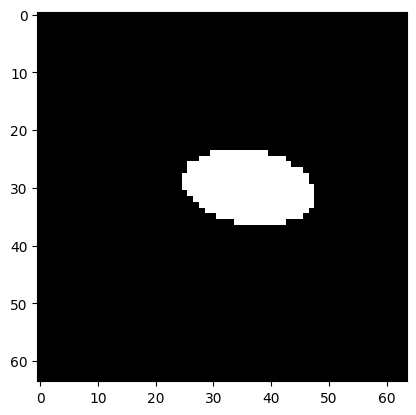

In [9]:
index_of_smaple_of_interest=0
print(batch_y[index_of_smaple_of_interest,:])
plt.imshow(batch_x[index_of_smaple_of_interest,:,:,:].squeeze(0),cmap='Greys_r')
plt.show()
index_of_smaple_of_interest=127
print(batch_y[index_of_smaple_of_interest,:])
plt.imshow(batch_x[index_of_smaple_of_interest,:,:,:].squeeze(0),cmap='Greys_r')

# 3 Models

## 3.1 Define the models
model definitions are in the model.py file. We have:

Model_1: Autoencoder : needs training<br>
Model_2: BetaVAE : needs training<br>
Model_3: FactorVAE : needs training<br>
Model_4: ResNet18Encoder : pretrained<br>

In [10]:
# ===== Model 1: AE (Autoencoder)# ================================================================
from models import Autoencoder
from utils import count_parameters, freeze_model
model_ae = Autoencoder(latent_dim=16)

x = torch.randn(8, 1, 64, 64)
x_logits, z = model_ae(x)
z= model_ae.encode(x) # this is how we can access the z directly
print("Input x:", x.shape)
print("Latent z:", z.shape)
print("Reconstruction logits:", x_logits.shape)
print("Trainable parameters:", count_parameters(model_ae))

Input x: torch.Size([8, 1, 64, 64])
Latent z: torch.Size([8, 16])
Reconstruction logits: torch.Size([8, 1, 64, 64])
Trainable parameters: 5593809


In [11]:
#========Model 2: β-VAE ============================================================
import importlib
import models
import train
importlib.reload(models)
importlib.reload(train)
from models import BetaVAE
from train import get_device
device = get_device()

model_BVAE = BetaVAE(latent_dim=16)

# Sanity check
x = torch.randn(8, 1, 64, 64)

x_logits, mu, logvar, z = model_BVAE(x)

print("Input x:", x.shape)
print("Reconstruction logits:", x_logits.shape)
print("mu:", mu.shape)
print("logvar:", logvar.shape)
print("sampled z:", z.shape)

print("Trainable parameters:", sum(p.numel() for p in model_BVAE.parameters() if p.requires_grad))

Input x: torch.Size([8, 1, 64, 64])
Reconstruction logits: torch.Size([8, 1, 64, 64])
mu: torch.Size([8, 16])
logvar: torch.Size([8, 16])
sampled z: torch.Size([8, 16])
Trainable parameters: 1578721


In [12]:
# ============================================================# Model 3: β-TCVAE# ============================================================

import importlib
import torch

import models
import train

importlib.reload(models)
importlib.reload(train)

from models import BetaTCVAE
from train import get_device

device = get_device()

model_BTCVAE = BetaTCVAE(latent_dim=16)

x = torch.randn(8, 1, 64, 64)

x_logits, mu, logvar, z = model_BTCVAE(x)

print("Input x:", x.shape)
print("Reconstruction logits:", x_logits.shape)
print("mu:", mu.shape)
print("logvar:", logvar.shape)
print("sampled z:", z.shape)

Input x: torch.Size([8, 1, 64, 64])
Reconstruction logits: torch.Size([8, 1, 64, 64])
mu: torch.Size([8, 16])
logvar: torch.Size([8, 16])
sampled z: torch.Size([8, 16])


# 3.2 Train the models that need training
The goal is to get the frozen encoder:
$$z = f_\theta(x)$$
so we can test our probes and methods to evalaute the disentanglement

Loaded checkpoint from: ./checkpoints/best_autoencoder_latent16.pt
Checkpoint epoch: 10
Checkpoint val loss: 0.00161


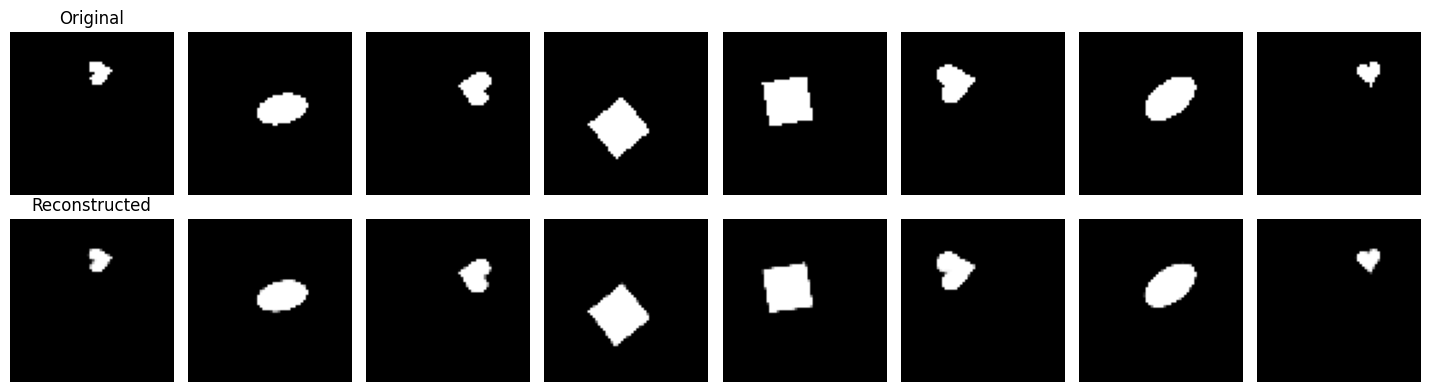

In [14]:
# ===== Model 1: AE (Autoencoder)# ================================================================

from models import Autoencoder
from train import train_or_load_autoencoder, extract_representations, get_device
from train import plot_training_history


device = get_device()

config = {
    "model_name": "Autoencoder",
    "latent_dim": 16,
    "lr": 1e-3,
    "num_epochs": 10,
    "batch_size": 128,
}

model_AE = Autoencoder(latent_dim=config["latent_dim"])

model_AE, history, checkpoint = train_or_load_autoencoder(
    model=model_AE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config["num_epochs"],
    lr=config["lr"],
    device=device,
    checkpoint_path="./checkpoints/best_autoencoder_latent16.pt",
    force_train=False, # means if we have a saved model already, we will use it
    config=config,
)

model_AE = freeze_model(model_AE)


# ------------ Optional: if i want to look at a reconstructed representation:

#
# import importlib
# import utils

# importlib.reload(utils)
from utils import show_reconstructions

show_reconstructions(model_AE, test_loader, device, n=8)

Loaded checkpoint from: ./checkpoints/best_beta_vae_latent16_beta4.pt
Checkpoint epoch: 10
Checkpoint val loss: 44.77132


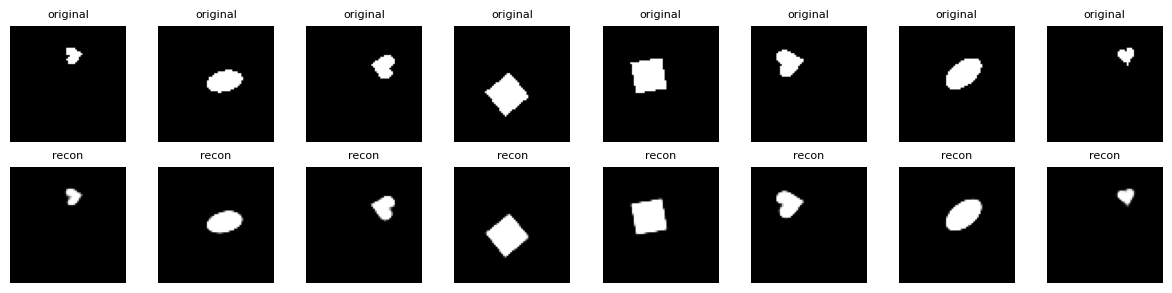

In [16]:
#========Model 2: β-VAE ============================================================

from models import BetaVAE
from train import train_or_load_beta_vae, freeze_model, get_device
from train import plot_training_history, reconstruct_batch_beta_vae


device = get_device()

config_BVAE = {
    "model_name": "BetaVAE",
    "latent_dim": 16,
    "beta": 1.0,
    "lr": 1e-3,
    "num_epochs": 10,
    "batch_size": 128,
}

model_BVAE = BetaVAE(latent_dim=config_BVAE["latent_dim"])

model_BVAE, history_BVAE, checkpoint_BVAE = train_or_load_beta_vae(
    model=model_BVAE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config_BVAE["num_epochs"],
    lr=config_BVAE["lr"],
    beta=config_BVAE["beta"],
    device=device,
    checkpoint_path="./checkpoints/best_beta_vae_latent16_beta4.pt",
    force_train=False,
    config=config_BVAE,
)

model_BVAE = freeze_model(model_BVAE)


# Manual β-VAE reconstruction plot
batch = next(iter(test_loader))
x = batch["x"][:8].to(device)

x_recon = reconstruct_batch_beta_vae(
    model=model_BVAE,
    x=x,
    device=device,
)

x_cpu = x.detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    axes[0, i].imshow(x_cpu[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(x_recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    axes[1, i].set_title("recon", fontsize=8)

plt.tight_layout()
plt.show()

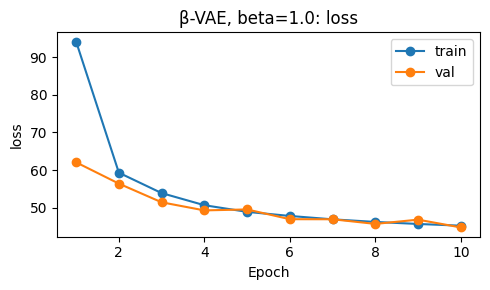

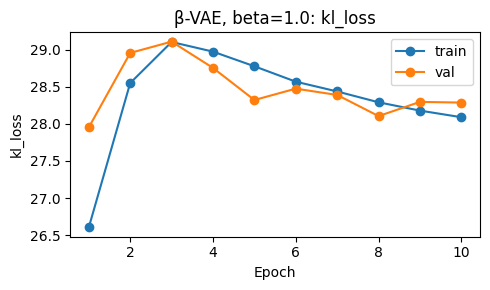

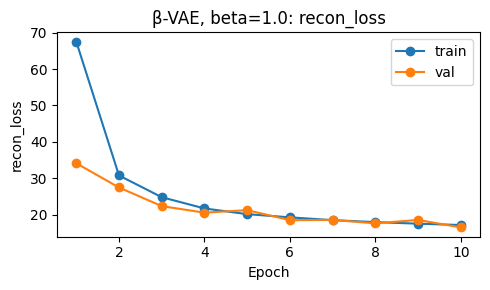

In [17]:
from train import plot_training_history

plot_training_history(
    history_BVAE,
    title=f"β-VAE, beta={config_BVAE['beta']}",
)

Loaded checkpoint from: ./checkpoints/best_beta_tcvae_latent16_tc4.pt
Checkpoint epoch: 20
Checkpoint val loss: 94.04815


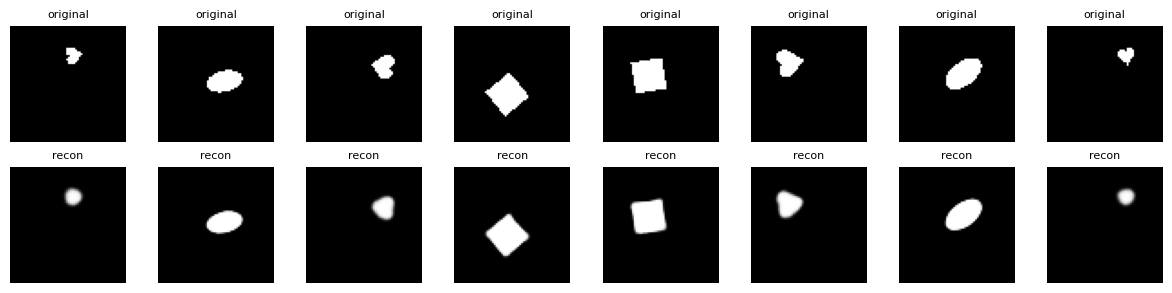

In [20]:
# ============================================================# Train / load β-TCVAE# ============================================================
from models import BetaTCVAE
from train import train_or_load_beta_tcvae, freeze_model, get_device, reconstruct_batch_beta_tcvae

device = get_device()

config_BTCVAE = {
    "model_name": "BetaTCVAE",
    "latent_dim": 16,
    "alpha_mi": 1.0,
    "beta_tc": 6.0,
    "gamma_dwkl": 1.0,
    "lr": 2*1e-4,
    "num_epochs": 20,
    "batch_size": 128,
}

model_BTCVAE = BetaTCVAE(
    latent_dim=config_BTCVAE["latent_dim"],
)

model_BTCVAE, history_BTCVAE, checkpoint_BTCVAE = train_or_load_beta_tcvae(
    model=model_BTCVAE,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=config_BTCVAE["num_epochs"],
    lr=config_BTCVAE["lr"],
    alpha_mi=config_BTCVAE["alpha_mi"],
    beta_tc=config_BTCVAE["beta_tc"],
    gamma_dwkl=config_BTCVAE["gamma_dwkl"],
    device=device,
    checkpoint_path="./checkpoints/best_beta_tcvae_latent16_tc4.pt",
    force_train=False,
    config=config_BTCVAE,
)

model_BTCVAE = freeze_model(model_BTCVAE)


batch = next(iter(test_loader))
x = batch["x"][:8].to(device)

x_recon = reconstruct_batch_beta_tcvae(
    model=model_BTCVAE,
    x=x,
    device=device,
)

x_cpu = x.detach().cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3))

for i in range(8):
    axes[0, i].imshow(x_cpu[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].axis("off")
    axes[0, i].set_title("original", fontsize=8)

    axes[1, i].imshow(x_recon[i].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
    axes[1, i].set_title("recon", fontsize=8)

plt.tight_layout()
plt.show()

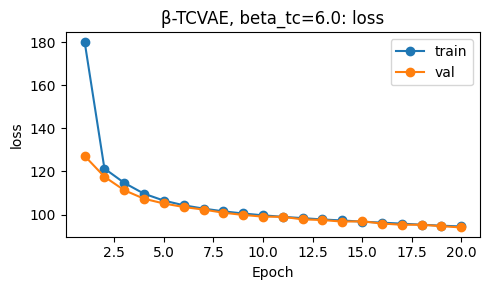

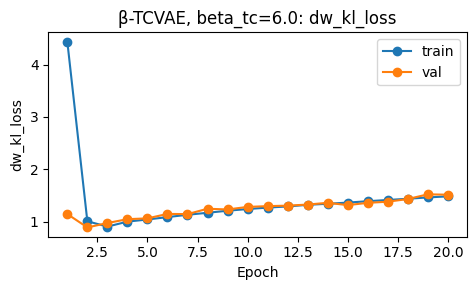

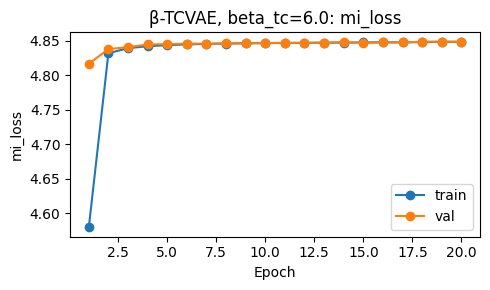

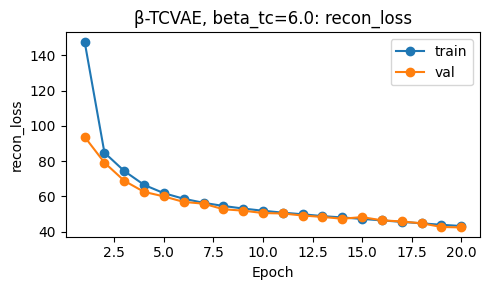

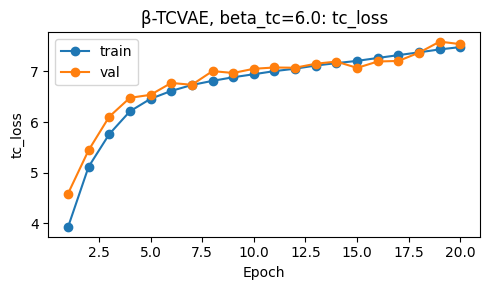

In [21]:
from train import plot_training_history

plot_training_history(
    history_BTCVAE,
    title=f"β-TCVAE, beta_tc={config_BTCVAE['beta_tc']}",
)

# 4. Make paired transformations:
This step do one job, creating:
$$(x, x'), p = (x, T_p(x))$$
and return the transformation parameter
p, so the same paired dataset can be reused for invariance and equivariance analysis.<br>
bellow we will create many of these pairs for our evalautison

Created paired datasets:
T_x_position    | n = 12000 | p_dim = 1 | p_names = ['delta_x_position_norm']
T_scale         | n = 12000 | p_dim = 1 | p_names = ['delta_scale_norm']
T_noise         | n = 12000 | p_dim = 1 | p_names = ['sigma']
T_mask          | n = 12000 | p_dim = 5 | p_names = ['x0_norm', 'y0_norm', 'dx_from_object_center_norm', 'dy_from_object_center_norm', 'patch_size_norm']


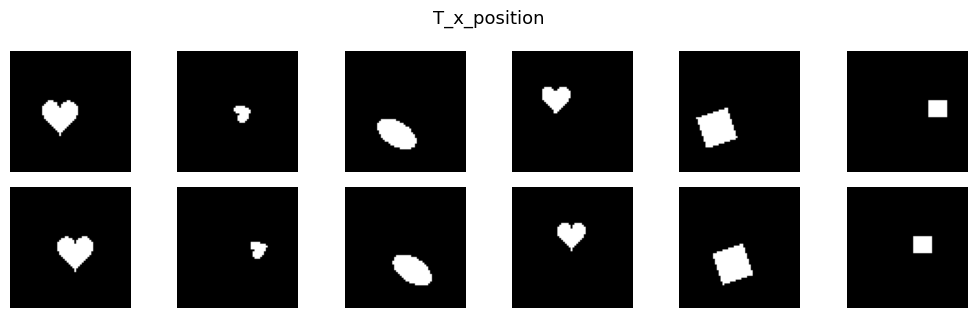

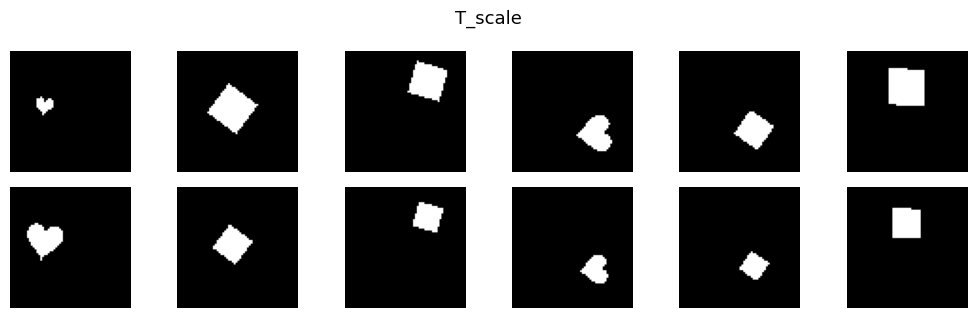

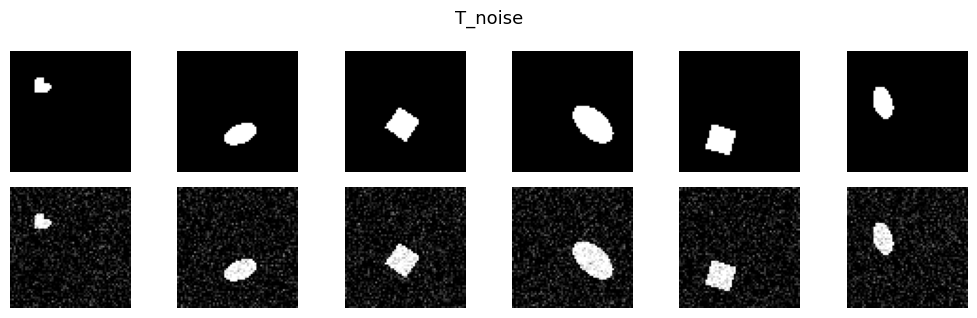

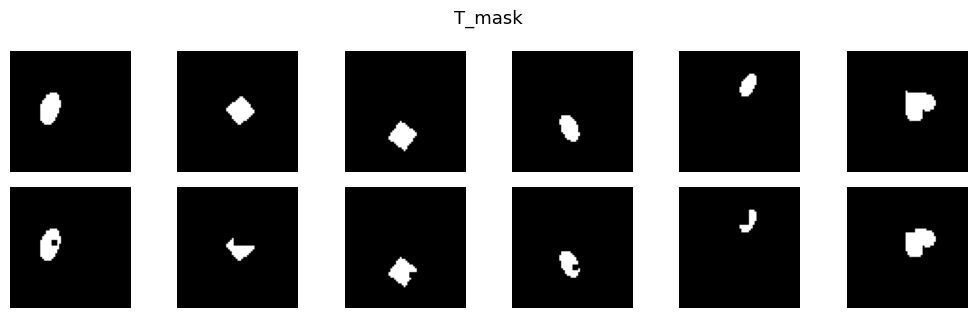

Mask dataset summary:
  n pairs: 12000
  mask mode: object_center
  mean object fraction occluded: 0.13756759774558264
  min object fraction occluded:  0.02368421052631579
  max object fraction occluded:  1.0
Created pair loaders:

T_x_position
x:        torch.Size([256, 1, 64, 64])
x_prime:  torch.Size([256, 1, 64, 64])
p:        torch.Size([256, 1])

T_scale
x:        torch.Size([256, 1, 64, 64])
x_prime:  torch.Size([256, 1, 64, 64])
p:        torch.Size([256, 1])

T_noise
x:        torch.Size([256, 1, 64, 64])
x_prime:  torch.Size([256, 1, 64, 64])
p:        torch.Size([256, 1])

T_mask
x:        torch.Size([256, 1, 64, 64])
x_prime:  torch.Size([256, 1, 64, 64])
p:        torch.Size([256, 5])


In [42]:
import importlib
import numpy as np
import torch
from torch.utils.data import DataLoader

import transformations
importlib.reload(transformations)

from transformations import (
    create_factor_pair_dataset,
    create_noise_pair_dataset,
    create_mask_pair_dataset,
    show_pair_examples,
    summarize_mask_dataset,
)


# ------------------------------------------------------------
# 4.1 Use the existing dSprites objects
# ------------------------------------------------------------

imgs = X
latents_classes_all = Y_classes

# Convert to numpy if needed.
# transformations.py is written to work with numpy arrays.
if torch.is_tensor(imgs):
    imgs = imgs.detach().cpu().numpy()

if torch.is_tensor(latents_classes_all):
    latents_classes_all = latents_classes_all.detach().cpu().numpy()

imgs = np.asarray(imgs)
latents_classes_all = np.asarray(latents_classes_all)


# ------------------------------------------------------------
# 4.2 Create paired datasets
# ------------------------------------------------------------
#
# Transformations:
#
#   T_x_position : change x-position only
#   T_scale      : change scale only
#   T_noise      : add Gaussian pixel noise
#   T_mask       : object-aware partial occlusion
#
# For T_mask:
#   mask center is sampled around the object center
#   mask size is also sampled with Gaussian variability
# ------------------------------------------------------------

N_PAIRS = 12000
SEED = 7

# Mask parameters
MASK_BASE_SIZE = 5
MASK_CENTER_SIGMA = 10.0
MASK_SIZE_SIGMA = 3.0
MASK_MIN_SIZE = 3
MASK_MAX_SIZE = 10
MASK_MIN_OBJECT_FRACTION = 0.05

pair_datasets = {
    "T_x_position": create_factor_pair_dataset(
        imgs=imgs,
        latents_classes=latents_classes_all,
        factor_name="x_position",
        n_pairs=N_PAIRS,
        seed=SEED,
        delta_choices=[-8, 8],
        p_mode="delta_norm",
    ),

    "T_scale": create_factor_pair_dataset(
        imgs=imgs,
        latents_classes=latents_classes_all,
        factor_name="scale",
        n_pairs=N_PAIRS,
        seed=SEED + 1,
        delta_choices=[-2, 5],
        p_mode="delta_norm",
    ),

    "T_noise": create_noise_pair_dataset(
        imgs=imgs,
        n_pairs=N_PAIRS,
        sigma=0.15,
        seed=SEED + 2,
    ),

    "T_mask": create_mask_pair_dataset(
        imgs=imgs,
        n_pairs=N_PAIRS,
        patch_size=MASK_BASE_SIZE,
        seed=SEED + 3,
        mask_mode="object_center",

        # Gaussian variability in mask center
        gaussian_center=True,
        center_sigma=MASK_CENTER_SIGMA,

        # Gaussian variability in mask size
        gaussian_size=True,
        size_sigma=MASK_SIZE_SIGMA,
        min_patch_size=MASK_MIN_SIZE,
        max_patch_size=MASK_MAX_SIZE,

        # Object-aware mask quality control
        threshold=0.5,
        min_object_fraction_occluded=MASK_MIN_OBJECT_FRACTION,
        max_center_tries=50,

        transform_name="T_mask",
    ),
}

print("Created paired datasets:")
for name, ds in pair_datasets.items():
    print(
        f"{name:15s} | n = {len(ds):5d} | "
        f"p_dim = {ds.p_dim} | p_names = {ds.p_names}"
    )


# ------------------------------------------------------------
# 4.3 Visual sanity check
# ------------------------------------------------------------
#
# Top row:    original image x
# Bottom row: transformed image x_prime = T_p(x)
# ------------------------------------------------------------

for name, ds in pair_datasets.items():
    show_pair_examples(
        pair_dataset=ds,
        n_examples=6,
        title=name,
    )


# ------------------------------------------------------------
# 4.4 Inspect mask metadata
# ------------------------------------------------------------
#
# This checks whether the object-aware mask is actually covering
# part of the dSprites object.
# ------------------------------------------------------------

mask_records_df = summarize_mask_dataset(pair_datasets["T_mask"])

mask_records_df[
    [
        "mask_mode",
        "x0",
        "y0",
        "mask_cx",
        "mask_cy",
        "object_cx",
        "object_cy",
        "dx_from_object_center",
        "dy_from_object_center",
        "patch_size",
        "object_fraction_occluded",
    ]
].head()


# ------------------------------------------------------------
# 4.5 Inspect one paired sample
# ------------------------------------------------------------

sample = pair_datasets["T_x_position"][0]

x = sample["x"]
x_prime = sample["x_prime"]
p = sample["p"]

# print("One sample from T_x_position:")
# print("x shape:       ", x.shape)
# print("x_prime shape: ", x_prime.shape)
# print("p:             ", p)
# print("idx:           ", sample["idx"].item())
# print("idx_prime:     ", sample["idx_prime"].item())


# ------------------------------------------------------------
# 4.6 Inspect transformation metadata
# ------------------------------------------------------------

records_df = pair_datasets["T_x_position"].records_as_dataframe()
records_df.head()


# ------------------------------------------------------------
# 4.7 Create DataLoaders for later evaluation
# ------------------------------------------------------------

BATCH_SIZE = 256

pair_loaders = {
    name: DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
    )
    for name, ds in pair_datasets.items()
}

print("Created pair loaders:")
for name, loader in pair_loaders.items():
    batch = next(iter(loader))

    print(f"\n{name}")
    print("x:       ", batch["x"].shape)
    print("x_prime: ", batch["x_prime"].shape)
    print("p:       ", batch["p"].shape)

# 5-d invariance:
we will test
$$(x, x') \rightarrow F_\theta(x), F_\theta(x') \rightarrow \cos(z,z')$$


Goal:For each frozen model and each transformation T, compute:
$$ z   =   F_\theta(x') $$
$$ z' = F_\theta(x')=F_\theta(T(x)) $$ 


and we measure:

$$\mathrm{Inv}_p
=
\frac{1}{N}
\sum_{i=1}^{N}
\cos\left(f_\theta(x_i), f_\theta(T(x_i))\right)$$

device: cuda
Models to evaluate:
 - AE
 - β-VAE
 - β-TCVAE
Transformations to evaluate:
 - T_x_position
 - T_scale
 - T_noise
 - T_mask

Evaluating model: AE
  T_x_position    | Inv = 0.6848 ± 0.0769 | L2 shift = 27.8340
  T_scale         | Inv = 0.9006 ± 0.0988 | L2 shift = 17.3509
  T_noise         | Inv = 0.9614 ± 0.0225 | L2 shift = 10.1480
  T_mask          | Inv = 0.9795 ± 0.0367 | L2 shift = 5.5673

Evaluating model: β-VAE
  T_x_position    | Inv = 0.5339 ± 0.1375 | L2 shift = 3.0970
  T_scale         | Inv = 0.8697 ± 0.1240 | L2 shift = 1.5809
  T_noise         | Inv = 0.4027 ± 0.3024 | L2 shift = 3.5879
  T_mask          | Inv = 0.9546 ± 0.0736 | L2 shift = 0.7643

Evaluating model: β-TCVAE
  T_x_position    | Inv = 0.9048 ± 0.0396 | L2 shift = 1.1382
  T_scale         | Inv = 0.7930 ± 0.2157 | L2 shift = 1.5424
  T_noise         | Inv = 0.9846 ± 0.0086 | L2 shift = 0.6043
  T_mask          | Inv = 0.9315 ± 0.1081 | L2 shift = 0.7581


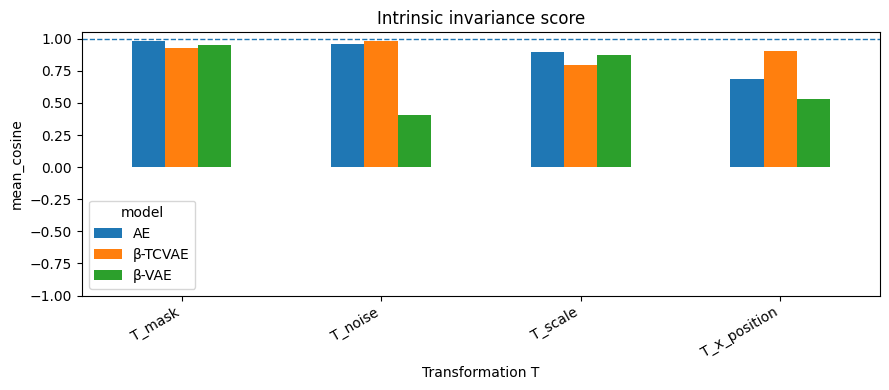

model,AE,β-TCVAE,β-VAE
transformation,,,
T_mask,0.979499,0.931464,0.954645
T_noise,0.961439,0.984601,0.402739
T_scale,0.900583,0.792985,0.869668
T_x_position,0.684830,0.904832,0.533888


In [43]:
# ============================================================
# 5. Invariance analysis
# ============================================================
#
# Goal:
#   For each frozen model and each transformation T, compute:
#
#       z       = F_theta(x)
#       z_prime = F_theta(T(x))
#
#   and measure:
#
#       Inv(T) = mean_i cos(z_i, z'_i)
#
# Higher Inv(T) means the representation is more stable
# under that transformation.
# ============================================================

import importlib
import torch
import pandas as pd

import invariance
importlib.reload(invariance)

from invariance import (
    run_invariance_analysis,
    plot_invariance_bar,
    plot_invariance_heatmap,
    plot_l2_shift_bar,
    plot_similarity_distributions,
    print_invariance_interpretation,
)


# ------------------------------------------------------------
# 5.1 Device
# ------------------------------------------------------------

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)


# ------------------------------------------------------------
# 5.2 Choose frozen models to evaluate
# ------------------------------------------------------------
#
# You can include or exclude AE here.
# For the cleanest comparison, start with β-VAE and β-TCVAE.
# ------------------------------------------------------------

models_to_test = {}

# Optional baseline
if "model_AE" in globals():
    models_to_test["AE"] = model_AE

if "model_BVAE" in globals():
    models_to_test["β-VAE"] = model_BVAE

if "model_BTCVAE" in globals():
    models_to_test["β-TCVAE"] = model_BTCVAE

if len(models_to_test) == 0:
    raise NameError(
        "No models found. Expected model_AE, model_BVAE, and/or model_BTCVAE."
    )

print("Models to evaluate:")
for model_name in models_to_test:
    print(" -", model_name)


# ------------------------------------------------------------
# 5.3 Check paired transformation loaders
# ------------------------------------------------------------

if "pair_loaders" not in globals():
    raise NameError(
        "pair_loaders not found. Run section 4: Build paired transformation datasets first."
    )

print("Transformations to evaluate:")
for transform_name in pair_loaders:
    print(" -", transform_name)


# ------------------------------------------------------------
# 5.4 Run invariance analysis
# ------------------------------------------------------------
#
# return_encoded=True keeps Z, Z_prime, and P.
# This is useful later for equivariance.
# If memory becomes an issue, set return_encoded=False.
# ------------------------------------------------------------

invariance_df, invariance_results = run_invariance_analysis(
    models=models_to_test,
    pair_loaders=pair_loaders,
    device=device,
    return_encoded=True,
    verbose=True,
)

invariance_df



# ============================================================
# 5.5 Plot invariance summary
# ============================================================

invariance_score_table = plot_invariance_bar(
    invariance_df,
    value_col="mean_cosine",
    title="Intrinsic invariance score",
    ylim=(-1.0, 1.05),
    figsize=(9, 4),
)

invariance_score_table

# 6 e-Equivaraince

device: cuda
Models:
 - AE
 - β-VAE
 - β-TCVAE

Transformations:
 - T_x_position
 - T_scale
 - T_noise
 - T_mask
Using encoded representations from invariance_results.

Evaluating model: AE
  T_x_position    | R2(model) = 0.7089 | R2(identity) = 0.3087 | gain = 0.4003
  T_scale         | R2(model) = 0.9245 | R2(identity) = 0.6873 | gain = 0.2372
  T_noise         | R2(model) = 0.9919 | R2(identity) = 0.8702 | gain = 0.1218
  T_mask          | R2(model) = 0.9653 | R2(identity) = 0.9545 | gain = 0.0108

Evaluating model: β-VAE
  T_x_position    | R2(model) = 0.4791 | R2(identity) = 0.0443 | gain = 0.4347
  T_scale         | R2(model) = 0.9528 | R2(identity) = 0.7133 | gain = 0.2396
  T_noise         | R2(model) = 0.9199 | R2(identity) = -2.4149 | gain = 3.3348
  T_mask          | R2(model) = 0.9168 | R2(identity) = 0.9052 | gain = 0.0116

Evaluating model: β-TCVAE
  T_x_position    | R2(model) = 0.9553 | R2(identity) = 0.7928 | gain = 0.1625
  T_scale         | R2(model) = 0.9303 | R2(id

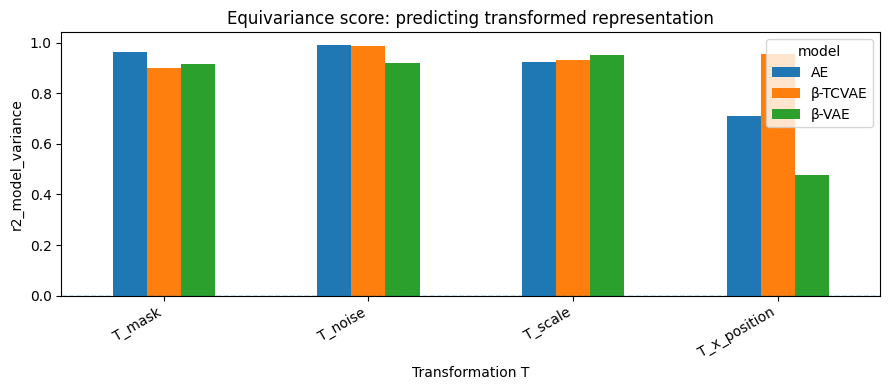

model,AE,β-TCVAE,β-VAE
transformation,,,
T_mask,0.965257,0.898844,0.916757
T_noise,0.991948,0.988217,0.919891
T_scale,0.924491,0.930281,0.952849
T_x_position,0.708937,0.955281,0.479056


In [45]:
# ============================================================
# 6. Equivariance analysis
# ============================================================
#
# Goal:
#   In invariance, we asked whether:
#
#       z' ≈ z
#
#   In equivariance, we ask whether:
#
#       z' is predictable from z and p
#
#   where:
#
#       x' = T_p(x)
#       z  = F_theta(x)
#       z' = F_theta(x')
#
# We fit a simple linear/ridge predictor:
#
#       z_hat' = z + g(z, p)
#
# and compare it against the identity baseline:
#
#       z_hat'_identity = z
#
# ============================================================

import importlib
import torch
import pandas as pd

import equivariance
importlib.reload(equivariance)

from equivariance import (
    run_equivariance_analysis_from_encoded,
    run_equivariance_analysis_from_loaders,
    plot_equivariance_bar,
    plot_equivariance_gain_bar,
    plot_identity_vs_model_r2,
    plot_equivariance_heatmap,
    plot_predicted_vs_true_dimension,
    print_equivariance_interpretation,
)


# ------------------------------------------------------------
# 6.1 Device
# ------------------------------------------------------------

if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("device:", device)


# ------------------------------------------------------------
# 6.2 Check models and paired loaders
# ------------------------------------------------------------

if "models_to_test" not in globals():
    models_to_test = {}

    if "model_AE" in globals():
        models_to_test["AE"] = model_AE

    if "model_BVAE" in globals():
        models_to_test["β-VAE"] = model_BVAE

    if "model_BTCVAE" in globals():
        models_to_test["β-TCVAE"] = model_BTCVAE

if len(models_to_test) == 0:
    raise NameError(
        "No models found. Expected model_AE, model_BVAE, and/or model_BTCVAE."
    )

if "pair_loaders" not in globals():
    raise NameError(
        "pair_loaders not found. Run section 4: Build paired transformation datasets first."
    )

print("Models:")
for model_name in models_to_test:
    print(" -", model_name)

print("\nTransformations:")
for transform_name in pair_loaders:
    print(" -", transform_name)


# ------------------------------------------------------------
# 6.3 Run equivariance analysis
# ------------------------------------------------------------
#
# If section 5 invariance was run with return_encoded=True,
# we can reuse the encoded Z, Z_prime, and P.
#
# Otherwise, this code will re-encode from the paired loaders.
# ------------------------------------------------------------

EQUIV_TARGET_MODE = "delta"
EQUIV_FEATURE_MODE = "z_p"
RIDGE_ALPHA = 1.0
TEST_SIZE = 0.25
SEED = 7

use_encoded_from_invariance = False

if "invariance_results" in globals():
    try:
        first_model_name = next(iter(invariance_results))
        first_transform_name = next(iter(invariance_results[first_model_name]))
        first_result = invariance_results[first_model_name][first_transform_name]

        use_encoded_from_invariance = all(
            key in first_result for key in ["Z", "Z_prime", "P"]
        )
    except Exception:
        use_encoded_from_invariance = False

if use_encoded_from_invariance:
    print("Using encoded representations from invariance_results.")

    equivariance_df, equivariance_results = run_equivariance_analysis_from_encoded(
        invariance_results=invariance_results,
        target_mode=EQUIV_TARGET_MODE,
        feature_mode=EQUIV_FEATURE_MODE,
        alpha=RIDGE_ALPHA,
        test_size=TEST_SIZE,
        seed=SEED,
        return_predictions=True,
        verbose=True,
    )

else:
    print("Encoded representations not found. Re-encoding from pair_loaders.")

    equivariance_df, equivariance_results = run_equivariance_analysis_from_loaders(
        models=models_to_test,
        pair_loaders=pair_loaders,
        device=device,
        target_mode=EQUIV_TARGET_MODE,
        feature_mode=EQUIV_FEATURE_MODE,
        alpha=RIDGE_ALPHA,
        test_size=TEST_SIZE,
        seed=SEED,
        return_predictions=True,
        verbose=True,
    )

equivariance_df


# ============================================================
# 6.4 Plot: main equivariance score
# ============================================================
#
# R2(model) asks:
#
#   how well can z' be predicted from z and p?
#
# Higher is better.
# ============================================================

equivariance_score_table = plot_equivariance_bar(
    equivariance_df,
    value_col="r2_model_variance",
    title="Equivariance score: predicting transformed representation",
    figsize=(9, 4),
)

equivariance_score_table

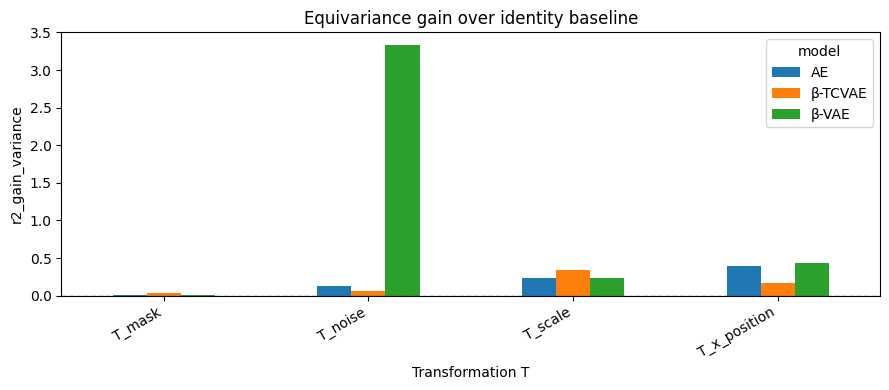

model,AE,β-TCVAE,β-VAE
transformation,,,
T_mask,0.010805,0.034197,0.011595
T_noise,0.121774,0.065487,3.334755
T_scale,0.237182,0.336948,0.239571
T_x_position,0.400274,0.162488,0.434711


In [46]:
# ============================================================
# 6.5 Plot: gain over identity baseline
# ============================================================
#
# This is the most important control.
#
# If identity baseline is already strong:
#
#   z' ≈ z
#
# then a high R2(model) may simply reflect invariance.
#
# Gain over identity asks whether p helps predict how z changes.
# ============================================================

equivariance_gain_table = plot_equivariance_gain_bar(
    equivariance_df,
    value_col="r2_gain_variance",
    title="Equivariance gain over identity baseline",
    figsize=(9, 4),
)

equivariance_gain_table